This notebook is modified from the example/channel_response.ipynb of the original repo: https://github.com/ant-uni-bremen/OpenNTN/

In [98]:
import os
from sionna.phy.channel import GenerateOFDMChannel
gpu_num = 0 # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Import Sionna
import sionna

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import matplotlib.pyplot as plt
import numpy as np

from sionna.phy.ofdm import ResourceGrid
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel

# These functions also exist in sionna.channel.tr38901 but are not compatable with 3GPP TR38.811
from sionna.phy.channel.tr38901 import Antenna, AntennaArray

In [99]:
# Import the NTN channel models from the local OpenNTN package
import sys
sys.path.append('../')  # Add parent directory to path to access OpenNTN
from OpenNTN import DenseUrban, Urban, SubUrban
from OpenNTN.utils import gen_single_sector_topology as gen_ntn_topology

In [100]:
scenario = "sur" # dur, sur, urb
carrier_frequency = 27e9 # DL S-Band
direction = "downlink"
elevation_angle = 50.0
num_ut = 1
satellite_height = 600000.0 # Height in meters, this is a satellite in the Low Earth Orbit (LEO)
batch_size = 32 # Number of topologies we will generate later  

In [101]:
ut_array = Antenna(polarization="single",
                    polarization_type="V",
                    antenna_pattern="omni",
                    carrier_frequency=carrier_frequency)

# The satellite is the basestation, so we name it bs. 
bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="dual",
                        polarization_type="VH",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)
N_samples = 2048


In [102]:
num_streams_per_tx = 1 
num_time_steps = 14
RBBlock = 11
nFFT = int(2** (np.ceil(np.log2(RBBlock * 12)))) 
SCS = 60e3
sampling_frequency = SCS * nFFT # set equal to waveformInfo.SampleRate in MATLAB
        # maybe different because in MATLAB, number of subcariers is different to the Nfft

rg = ResourceGrid(num_ofdm_symbols=14,
                    fft_size=nFFT, # 
                    subcarrier_spacing=SCS,
                    num_tx=num_ut,
                    num_streams_per_tx=num_streams_per_tx,
                    cyclic_prefix_length=26,
                    num_guard_carriers=(62, 62),     # 256 - 132 = 124 zeroed carriers
                    dc_null=False, 
                    pilot_pattern="kronecker",
                    pilot_ofdm_symbol_indices=[2,11])

# Function that calculates the subcarrier frequencies of the OFDM frame
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

In [103]:
from OpenNTN.utils import compute_stallite_doppler as compute_stallite_doppler 

In [104]:
aa = compute_stallite_doppler(satellite_height, elevation_angle, carrier_frequency)
aa

<tf.Tensor: shape=(), dtype=float32, numpy=27000400000.0>

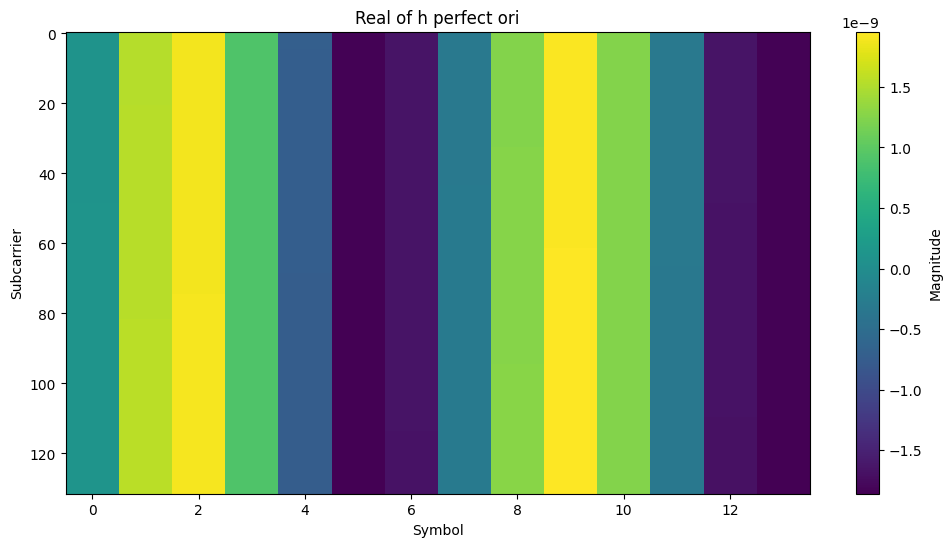

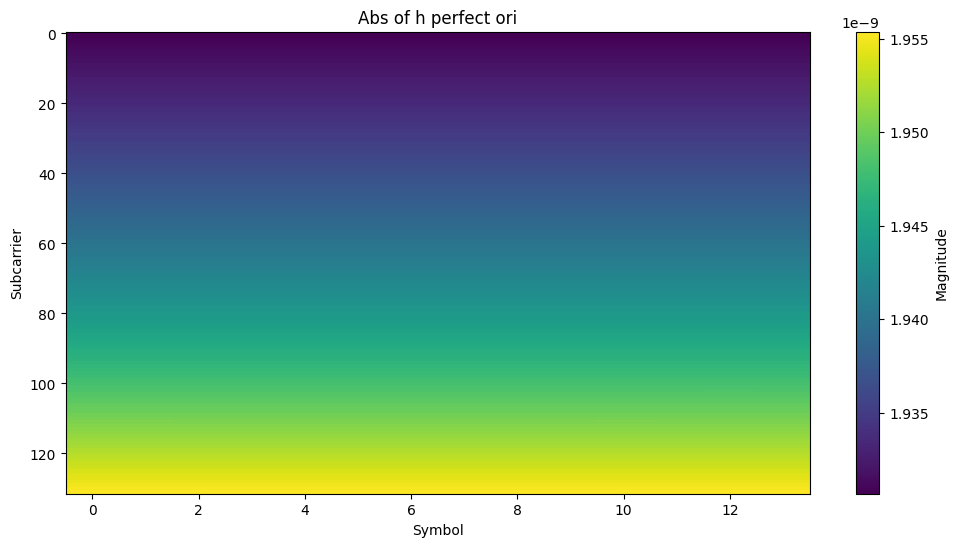

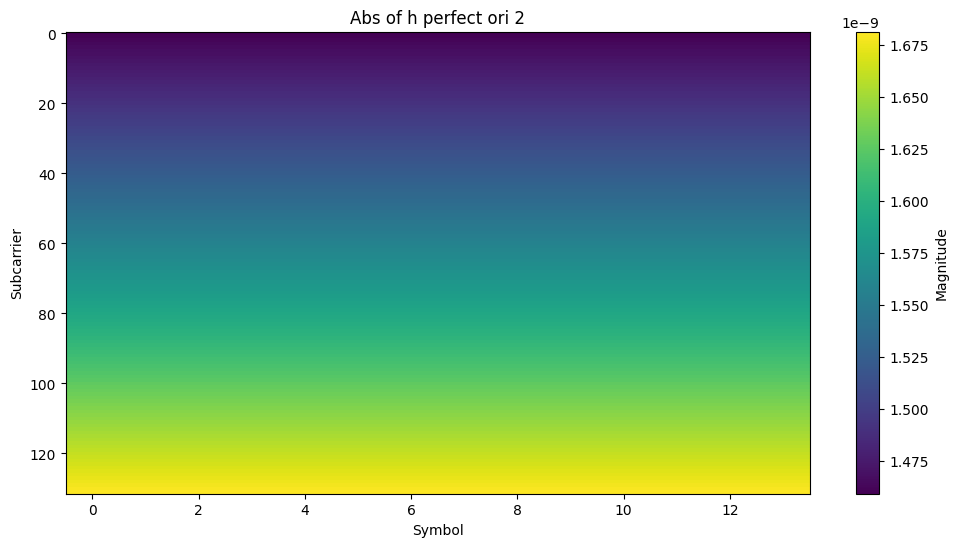

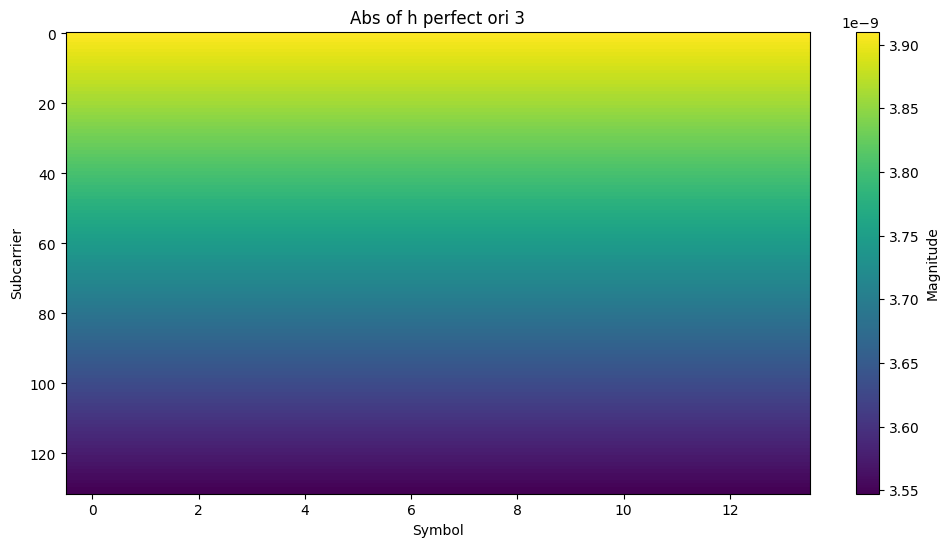

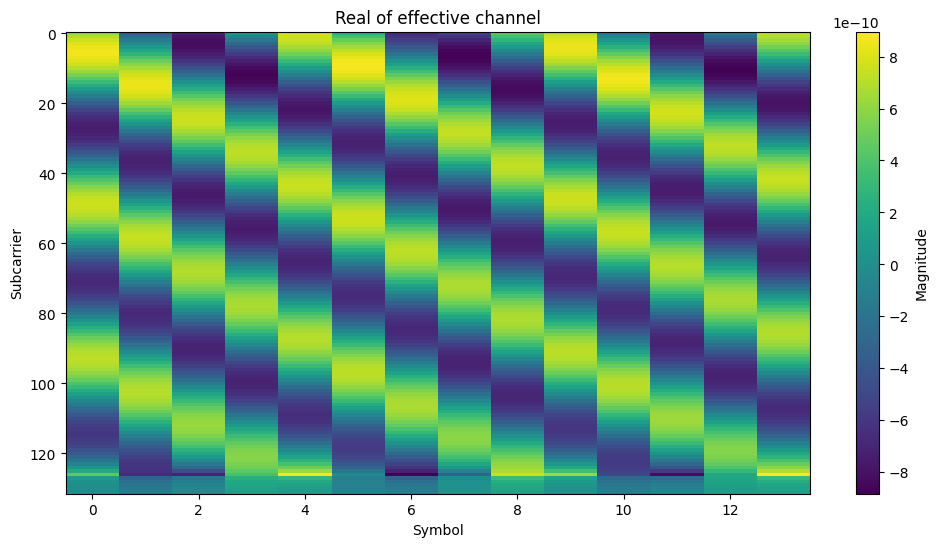

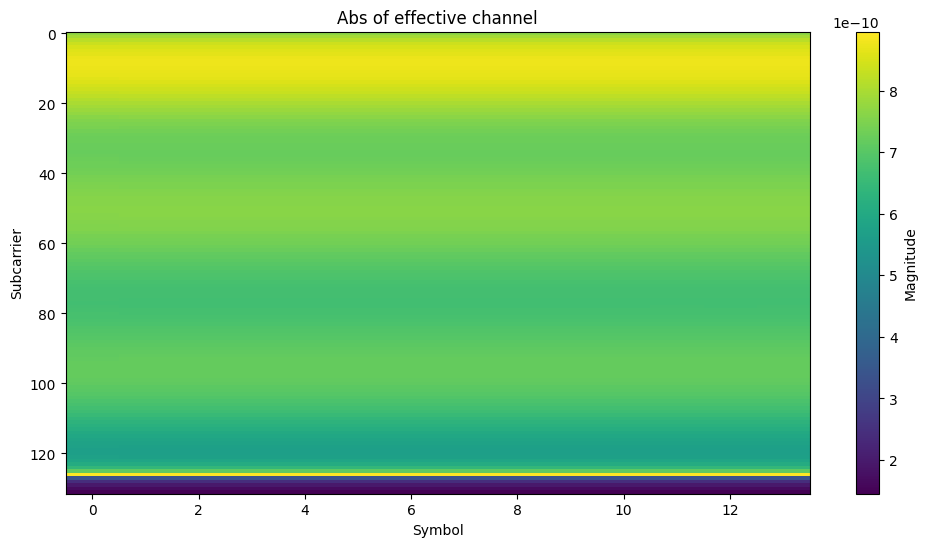

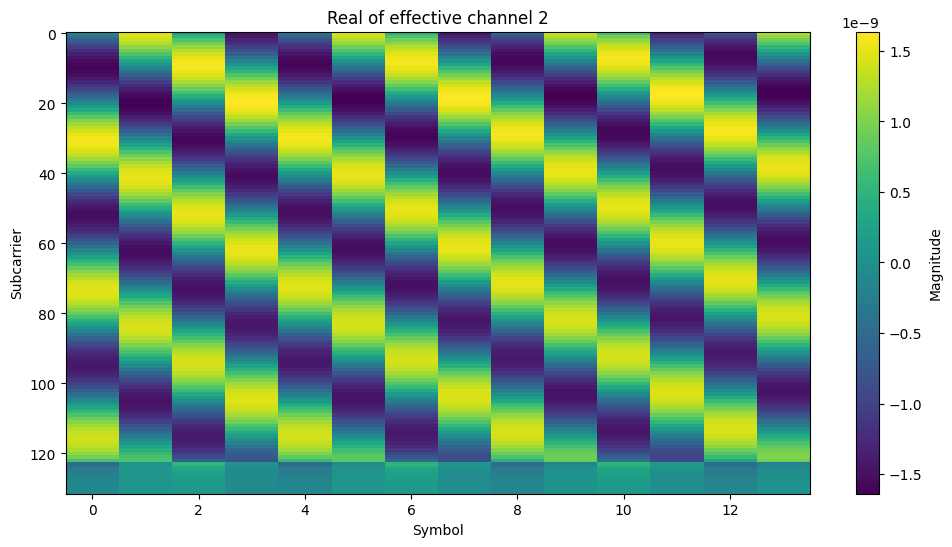

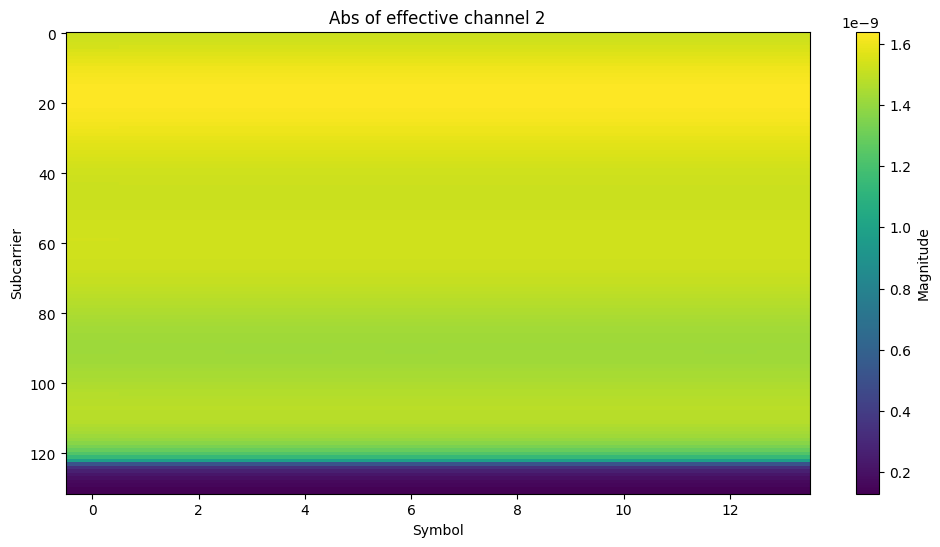

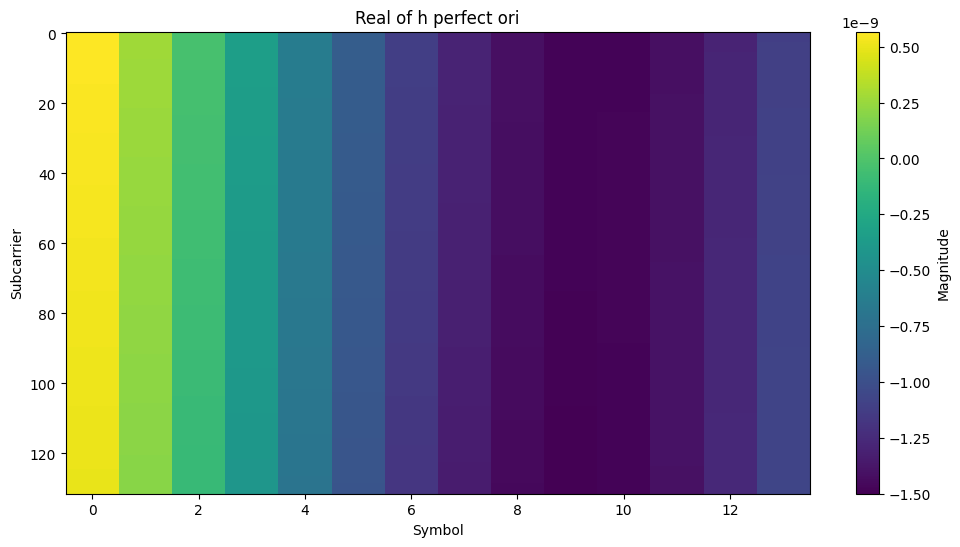

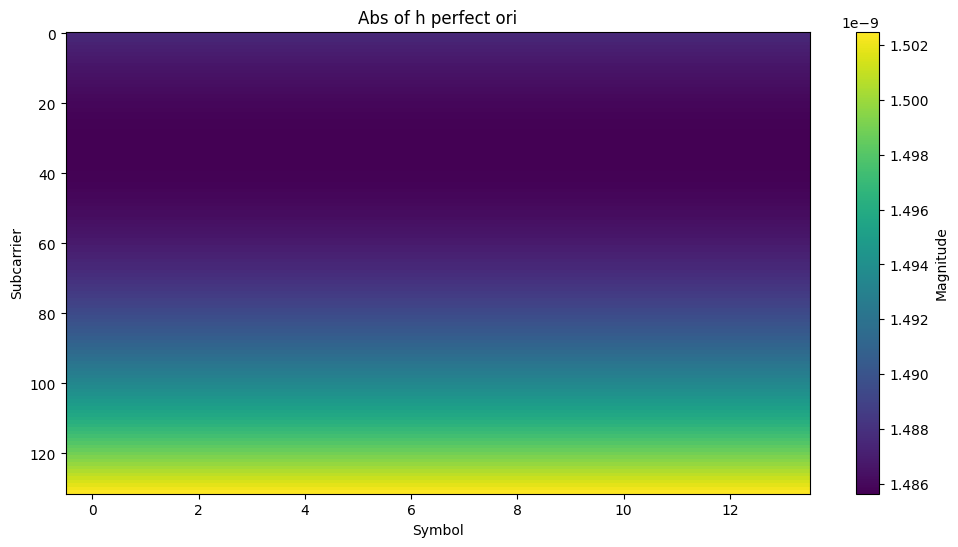

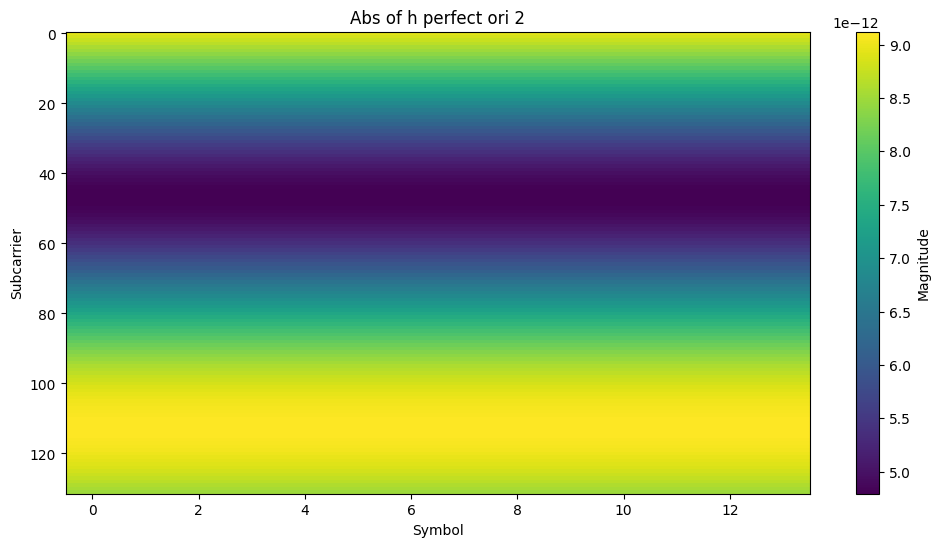

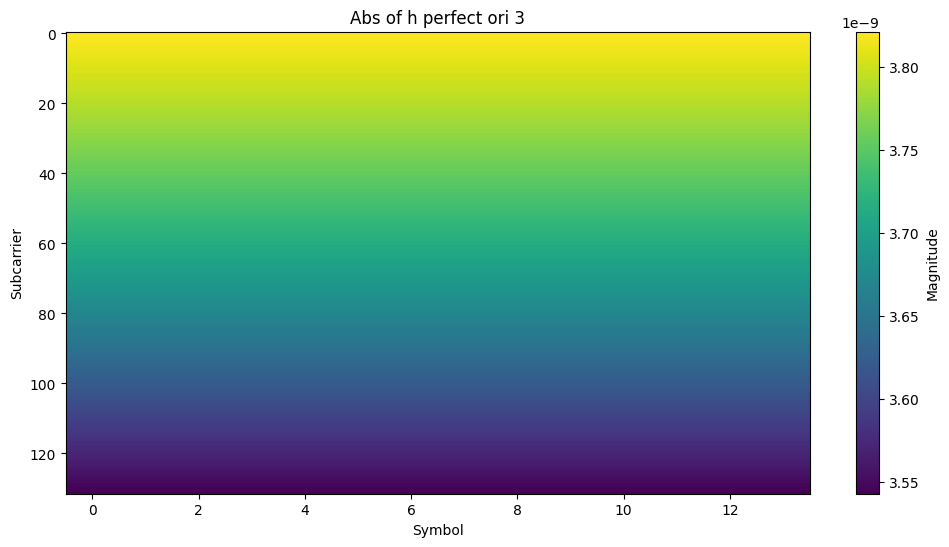

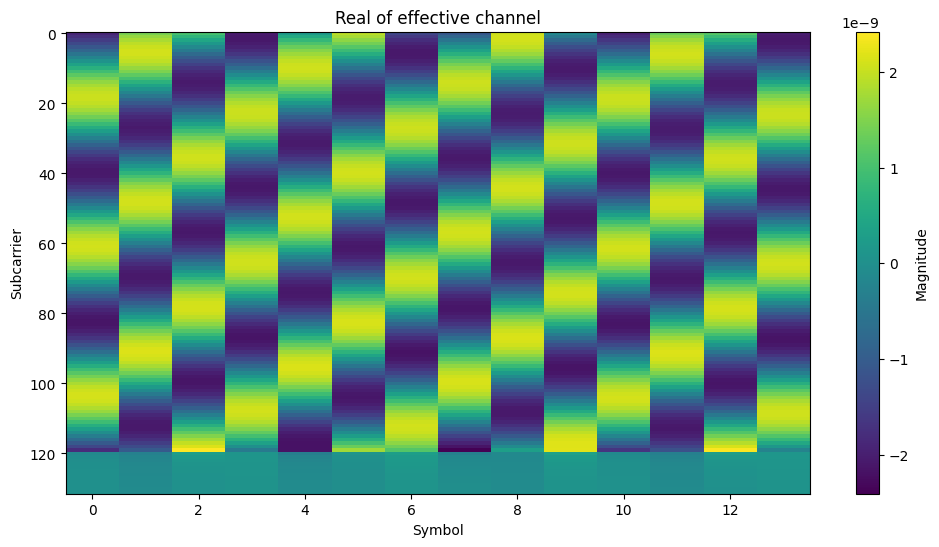

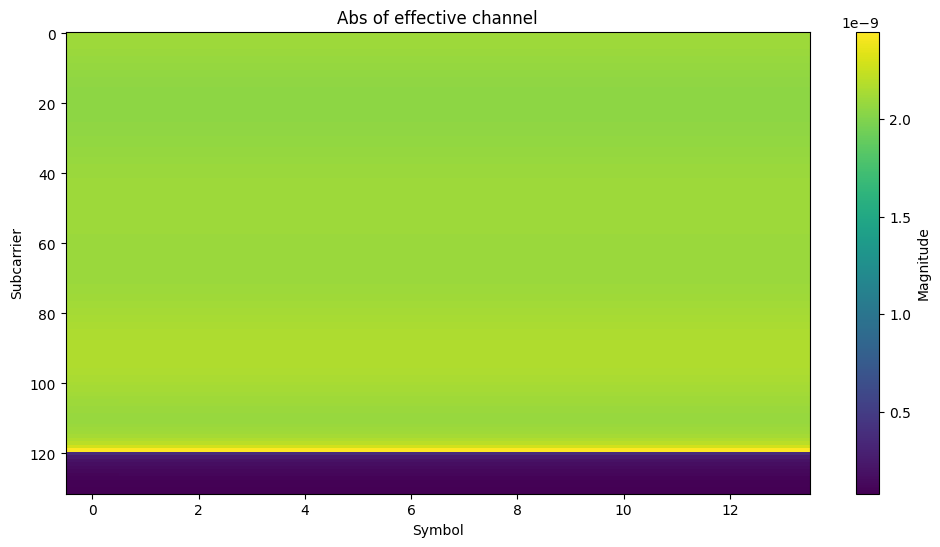

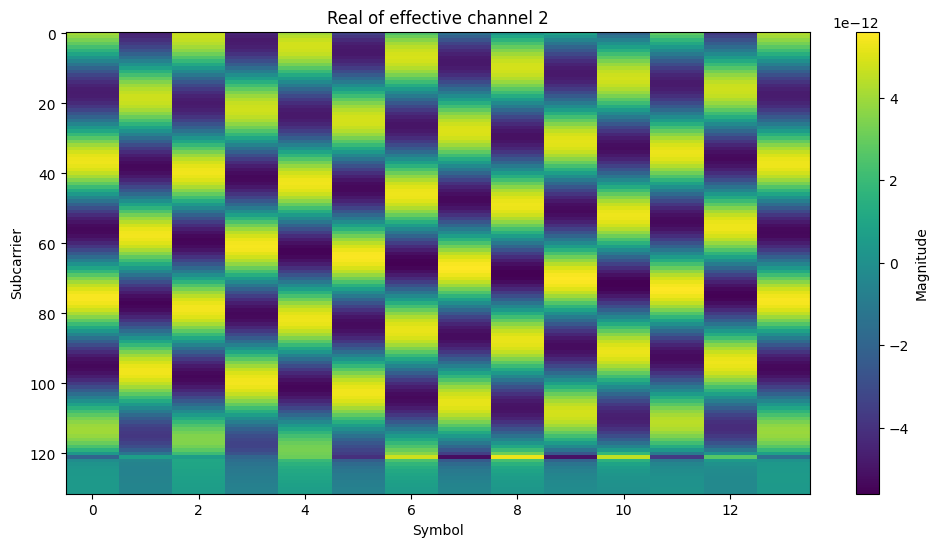

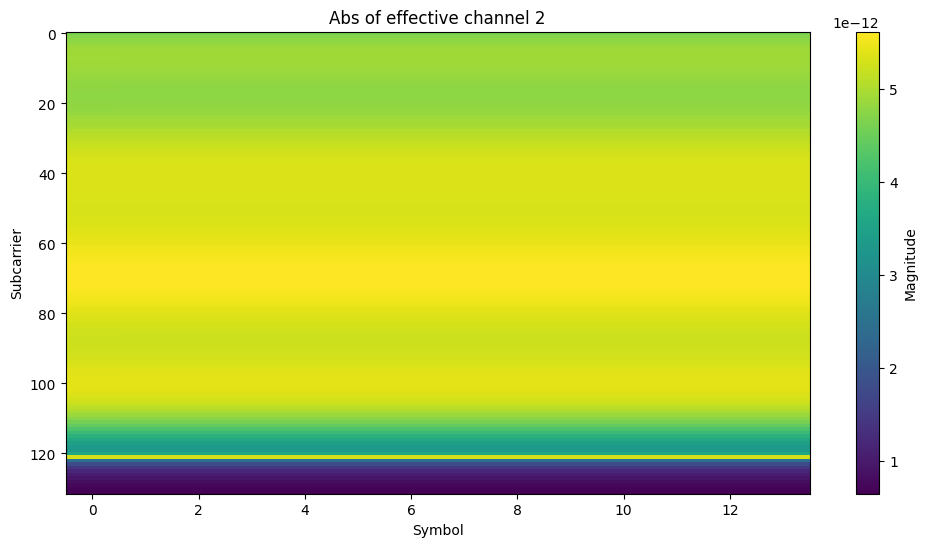

In [105]:
from OpenNTN.utils import cir_to_time_channel, time_lag_discrete_time_channel
from sionna.phy.ofdm import RemoveNulledSubcarriers
bandwidth = rg.fft_size * rg.subcarrier_spacing

# ue_height = 10

H_perfect = [] # to be in size of [14,132,N]
H_efficient = []
for i in range(2): # (N_samples//(batch_size *2)):
    # Here we match choose DenseUrban to match the parameter "dur" for the scenario defined above
    channel_model = SubUrban(carrier_frequency=carrier_frequency,
                            ut_array=ut_array,
                            bs_array=bs_array,
                            direction=direction,
                            elevation_angle=elevation_angle)

    # Generate the topology
    topology = gen_ntn_topology(batch_size=batch_size, num_ut=num_ut, scenario=scenario,bs_height=satellite_height)
    # topology = gen_ntn_topology(batch_size=batch_size, num_ut=num_ut, min_ut_height=ue_height, max_ut_height=ue_height, scenario=scenario,bs_height=satellite_height)

    # Set the topology
    channel_model.set_topology(*topology)

    # path_coefficients [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # path_delays [batch size, num_rx, num_tx, num_paths]
    num_time_steps = 14 * (rg.fft_size + rg.cyclic_prefix_length)
    # symbol_start = np.arange(1, 14) * 132
    # # symbol_start = np.concatenate(([22], np.arange(1, 14) * (132 + 18))) # 256       % including CP
    # symbol_start = tf.constant(symbol_start, dtype=tf.int32)
    path_coefficients, path_delays = channel_model(num_time_steps, sampling_frequency)
    # h = cir_to_ofdm_channel(frequencies, path_coefficients, path_delays)
    # Convert CIR -> discrete time-domain channel taps h_t[b, l]
    l_min, l_max = time_lag_discrete_time_channel(bandwidth)
    h_t = cir_to_time_channel(
        bandwidth=bandwidth,
        a=path_coefficients,
        tau=path_delays,
        l_min=l_min,
        l_max=l_max,
        normalize=False
    )
    
    ofdm_channel = GenerateOFDMChannel(channel_model, resource_grid=rg)
    h_freq= ofdm_channel()
    
    remove_nulled = RemoveNulledSubcarriers(rg)
    h_perfect_ori = remove_nulled(h_freq)   # -> [..., 14, 132]
    
    h_freq_plot = (h_perfect_ori[1,0,0,0,0,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of h perfect ori')
    plt.show()

    h_freq_plot = np.abs((h_perfect_ori[1,0,0,0,0,:,:]).numpy())
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Abs of h perfect ori')
    plt.show()

    h_freq_plot = np.abs((h_perfect_ori[2,0,0,0,0,:,:]).numpy())
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Abs of h perfect ori 2')
    plt.show()

    h_freq_plot = np.abs((h_perfect_ori[3,0,0,0,0,:,:]).numpy())
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Abs of h perfect ori 3')
    plt.show()
    
    sym_starts = tf.range(14, dtype=tf.int32) * (rg.fft_size + rg.cyclic_prefix_length) + rg.cyclic_prefix_length
    a_sym = tf.gather(path_coefficients, sym_starts, axis=-1)  # shape now has T=14
    h_f = cir_to_ofdm_channel(
        frequencies,   # from subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)
        a_sym,
        path_delays,
        normalize=False
    )

    h_1 = h_freq[:, 0, 0, 0, 0, :, :].numpy()  # Shape: [batch_size, 14, 132]
    h_2 = h_freq[:, 0, 0, 0, 1, :, :].numpy()  # Shape: [batch_size, 14, 132]

    h_1 = tf.transpose(h_1, perm=[1, 2, 0])  # (32,14,132) -> (14,132,32)
    h_2 = tf.transpose(h_2, perm=[1, 2, 0])  # (32,14,132) -> (14,132,32)
    H_perfect.append(h_1)
    H_perfect.append(h_2)
    
    #### txGrid Probe for Effective channel
    B = tf.shape(h_t)[0]  # batch size
    N_sym = rg.num_ofdm_symbols      # 14
    N_fft = rg.fft_size              # 256
    N_cp  = rg.cyclic_prefix_length  # 
    Fs = sampling_frequency

    # Your active band is centered: 62 left guards + 132 active + 62 right guards
    gL, gR = 62, 62
    N_act = 132
    assert N_fft == gL + N_act + gR

    # 1) txGrid: full ones on 14x132, then zero-pad -> 14x256
    tx_grid_132 = tf.ones([B, N_sym, N_act], dtype=tf.complex64)
    tx_grid_256 = tf.pad(tx_grid_132, paddings=[[0,0],[0,0],[gL,gR]])  # [B,14,256]

    # 2) OFDM modulate
    x_no_cp = tf.signal.ifft(tf.signal.ifftshift(tx_grid_256, axes=-1))  # [B,14,256]
    x_cp = tf.concat([x_no_cp[:, :, -N_cp:], x_no_cp], axis=-1)           # [B,14,256+CP]
    tx_waveform = tf.reshape(x_cp, [B, N_sym*(N_fft+N_cp)])               # [B,3864]

    # 3) Doppler pre-compensation (sample-wise)
     # Extract ONLY the Doppler shift frequency (approx +32.3 kHz)
    f_doppler = compute_stallite_doppler(satellite_height, elevation_angle, carrier_frequency) - carrier_frequency
    n = tf.cast(tf.range(tf.shape(tx_waveform)[-1]), tf.float32)  # [0..3863]
    rot = tf.exp(tf.complex(tf.zeros_like(n), -2 * np.pi * f_doppler * n / Fs))
    x_pc = tx_waveform * rot[None, :]

    # 4) Time-varying channel: y[n] = sum_l h_t[n,l] x[n-l]
    # h_t expected full shape: [B, Nr, NrAnt, Nt, NtAnt, T, L]
    h = h_t[:, 0, 0, 0, 0, :, :]  # [B,T,L]
    T = tf.shape(h)[1]
    L = tf.shape(h)[2]

    x_pad = tf.pad(x_pc, [[0,0],[L-1,0]])
    y = tf.zeros([B, T], dtype=tf.complex64)

    for l in tf.range(L):
        x_shift = x_pad[:, (L-1-l):(L-1-l+T)]
        y += h[:, :, l] * x_shift

    rx_waveform = y  # [B,3864]

    # 5) OFDM demodulate
    rx_sym = tf.reshape(rx_waveform, [B, N_sym, N_fft+N_cp])
    rx_no_cp = rx_sym[:, :, N_cp:]
    rx_grid_256 = tf.signal.fftshift(tf.signal.fft(rx_no_cp), axes=-1)    # [B,14,256]

    # 6) Take active 132 (center)
    rx_grid_132 = rx_grid_256[:, :, gL:gL+ N_act] # [B,14,132]

    # 7) Effective channel on active REs
    H_eff = rx_grid_132 / tx_grid_132   # tx_grid_132 is all ones -> H_eff == rx_grid_132
    
    h_freq_plot = (H_eff[1,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of effective channel')
    plt.show()

    h_freq_plot = np.abs((H_eff[1,:,:]).numpy())
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Abs of effective channel')
    plt.show()

    h_freq_plot = (H_eff[2,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of effective channel 2')
    plt.show()
    
    h_freq_plot = np.abs((H_eff[2,:,:]).numpy())
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Abs of effective channel 2')
    plt.show()

    # Check LoS status for all 32 topology drops in the batch
    channel_model._scenario.los.numpy().squeeze()
    
    

In [106]:
channel_model._scenario.los.numpy().squeeze()

array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [107]:
H_perfect

[<tf.Tensor: shape=(14, 256, 32), dtype=complex64, numpy=
 array([[[ 5.99486183e-10+1.7890507e-09j,  8.04865063e-11+1.9211446e-09j,
          -2.17891524e-10+1.3516706e-09j, ...,
           2.61553487e-11+7.8149592e-10j,  6.94526325e-10+2.9135916e-09j,
           5.17627552e-10+5.9394850e-10j],
         [ 5.95883065e-10+1.7855312e-09j,  8.08109690e-11+1.9212489e-09j,
          -2.19144911e-10+1.3528143e-09j, ...,
           2.55681917e-11+7.8195000e-10j,  6.94631574e-10+2.9160825e-09j,
           5.15839815e-10+5.9300392e-10j],
         [ 5.92182081e-10+1.7821051e-09j,  8.11339329e-11+1.9213537e-09j,
          -2.20395077e-10+1.3539626e-09j, ...,
           2.49882684e-11+7.8241330e-10j,  6.94745483e-10+2.9185749e-09j,
           5.14047471e-10+5.9206801e-10j],
         ...,
         [ 5.29460087e-10+1.7277803e-09j,  1.25907715e-10+1.9687449e-09j,
          -4.00871281e-10+1.7420719e-09j, ...,
          -7.57836502e-12+8.7398677e-10j,  9.94062721e-10+3.4850254e-09j,
           8.329895

In [108]:
(h_perfect_ori[1,:,:,0,0,0,0]).numpy().real

array([[5.670431e-10]], dtype=float32)

In [109]:
H_eff.shape

TensorShape([32, 14, 132])

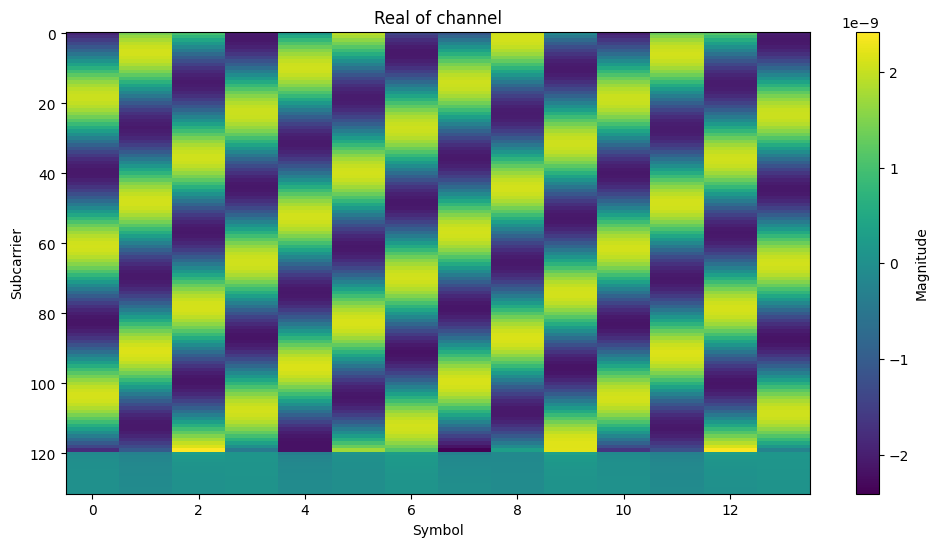

In [110]:
H_eff.shape
h_freq_plot = (H_eff[1,:,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

In [111]:
H_perfect = tf.concat(H_perfect, axis=-1) # H to save: [14, 132, N]
H_perfect.shape

TensorShape([14, 256, 128])

In [112]:
import scipy.io

H_perfect_numpy = H_perfect.numpy()
scipy.io.savemat('H_perfect_withoutDoppCom.mat', {'H_perfect': H_perfect_numpy})

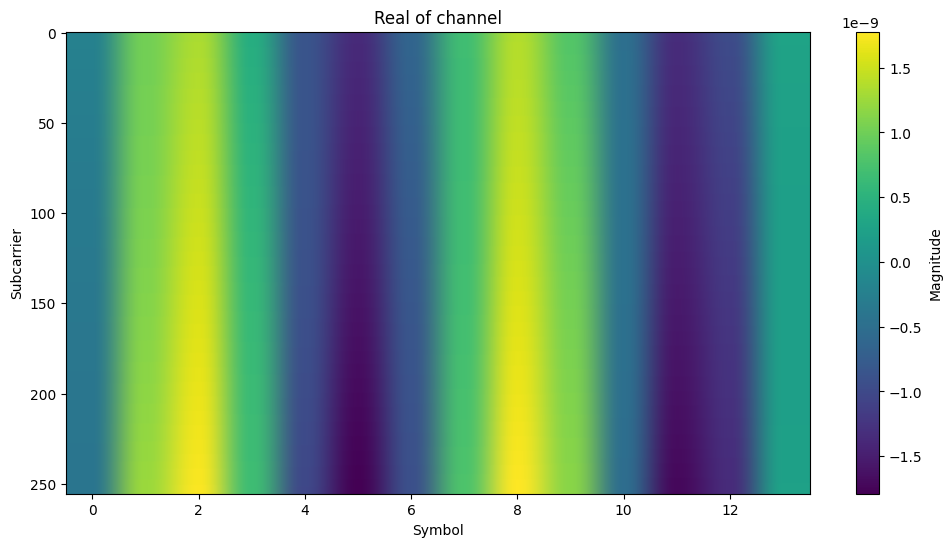

In [113]:
h_freq_plot = (H_perfect[:,:,2]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

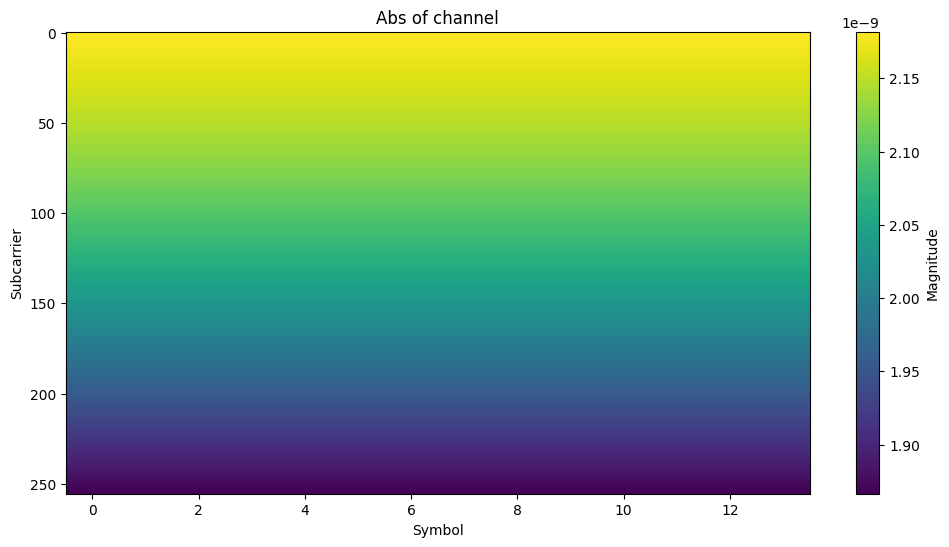

In [114]:
# h_freq_plot = (H_perfect[:,:,1]).numpy().real
h_freq_plot = tf.abs(H_perfect[:,:,11]).numpy()
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Abs of channel')
plt.show()

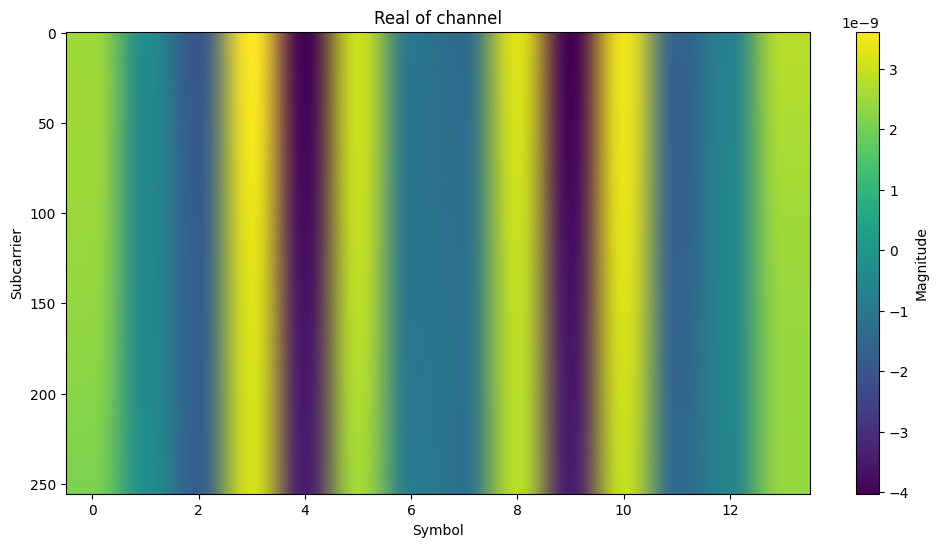

In [115]:
h_freq_plot = (H_perfect[:,:,3]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

In [116]:
h_freq_plot = (h[2,  0,0,  0,0,  :,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} Index out of range using input dim 3; input has only 3 dims [Op:StridedSlice] name: strided_slice/

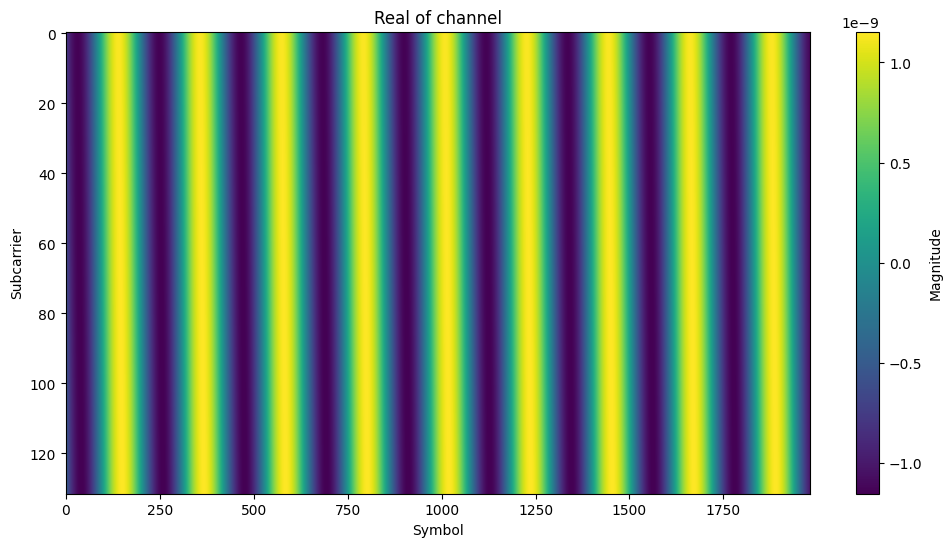

In [ ]:
h_freq_plot = (h[19,  0,0,  0,1,  :,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

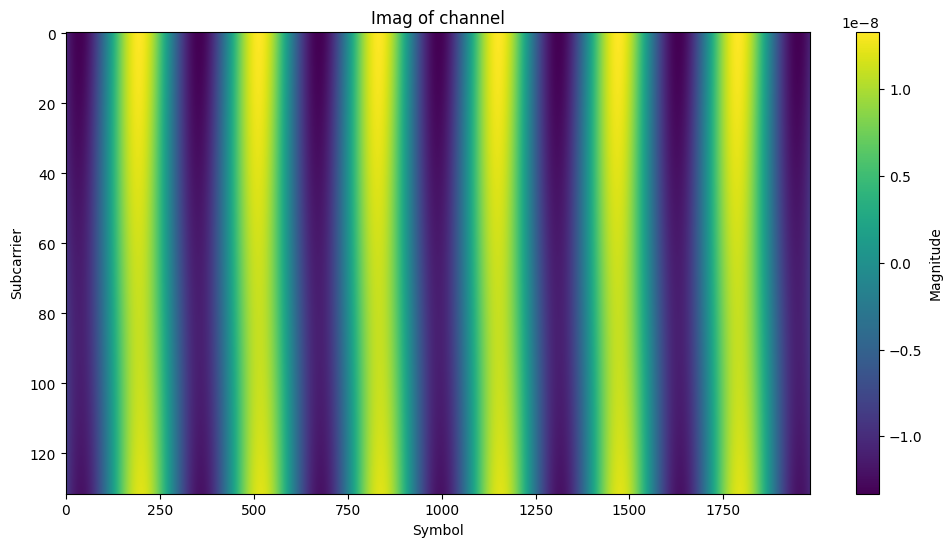

In [ ]:
h_freq_plot = (h[0,0,0,0,0,:,:]).numpy().imag
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Imag of channel')
plt.show()

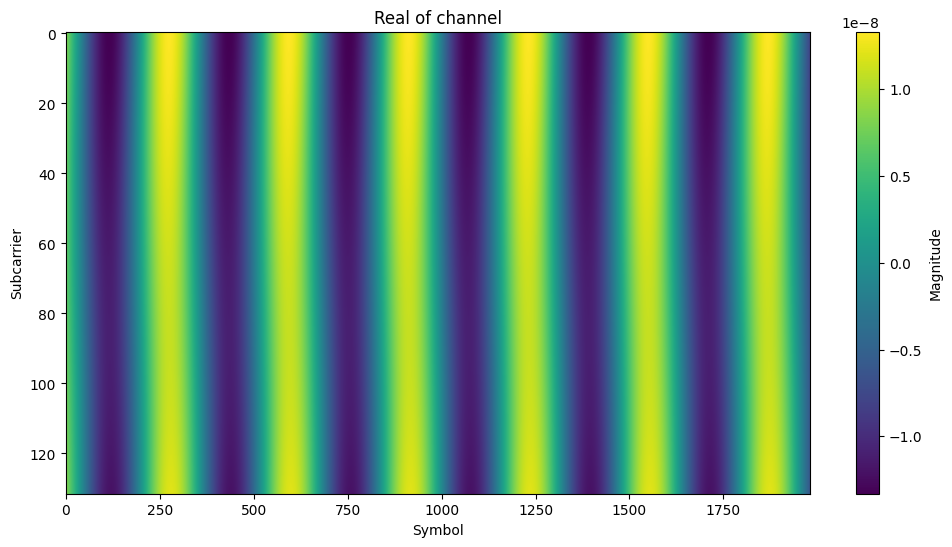

In [ ]:
h_freq_plot = (h[0,0,0,0,0,:,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

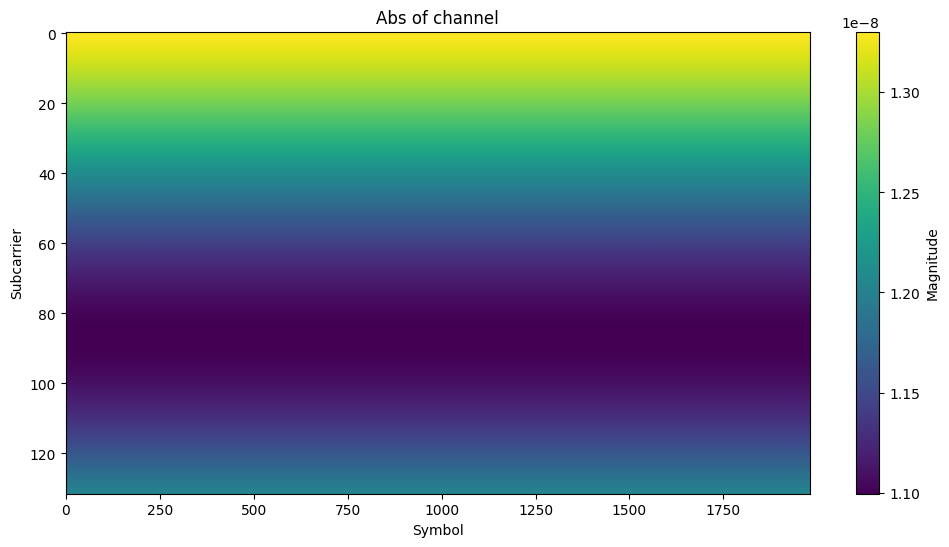

In [ ]:
h_freq_plot = tf.abs(h[0,0,0,0,0,:,:]).numpy() 
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Abs of channel')
plt.show()